## Doprinos 2

In [14]:
import sys
!{sys.executable} -m pip install colorednoise soundfile

In [15]:
import numpy as np
import soundfile as sf
import colorednoise as cn

In [76]:
import numpy as np
import soundfile as sf
import colorednoise as cn
import os

os.makedirs("audio/snr_test", exist_ok=True)

audio, sr = sf.read("audio/govor30.wav")

if audio.ndim > 1:
    audio = audio.mean(axis=1)

audio = audio / np.max(np.abs(audio))

def dodaj_sum_snr(signal, noise, snr_db):
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (10 ** (snr_db / 10))
    noise_scaled = noise * np.sqrt(target_noise_power / noise_power)

    noisy_signal = signal + noise_scaled
    noisy_signal = noisy_signal / np.max(np.abs(noisy_signal))

    return noisy_signal

snr_vrednosti = [20, 10, 5, 0, -5, -10, -15]

tipovi_suma = {
    "beli": lambda n: np.random.normal(0, 1, n),
    "pink": lambda n: cn.powerlaw_psd_gaussian(1, n)
}

for snr_db in snr_vrednosti:
    for naziv_suma, generator in tipovi_suma.items():
        noise = generator(len(audio))
        audio_sum = dodaj_sum_snr(audio, noise, snr_db)

        putanja = f"audio/snr_test/govor30_{naziv_suma}_{snr_db}db.wav"
        sf.write(putanja, audio_sum, sr)

print("Svi fajlovi sa različitim SNR vrednostima su sačuvani.")

Svi fajlovi sa različitim SNR vrednostima su sačuvani.


In [77]:
from faster_whisper import WhisperModel
from jiwer import wer

referenca = """
Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech. Automatic speech recognition enables the conversion of audio signals into text and is widely used in modern applications. Deep learning based models have significantly improved the quality and speed of speech processing.
"""

model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

In [78]:
def izracunaj_wer(audio_fajl):
    segments, info = model.transcribe(
        audio_fajl,
        language="en"
    )

    tekst = ""

    for segment in segments:
        tekst += segment.text + " "

    greska = wer(
        referenca.lower().strip(),
        tekst.lower().strip()
    )

    return greska, tekst.strip()

In [79]:
import pandas as pd

rezultati = []

wer_bez, tekst_bez = izracunaj_wer("audio/govor30.wav")

rezultati.append({
    "Tip šuma": "bez šuma",
    "SNR [dB]": "∞",
    "WER [%]": round(wer_bez * 100, 2),
    "Transkripcija": tekst_bez
})

for snr_db in snr_vrednosti:
    for naziv_suma in ["beli", "pink"]:
        putanja = f"audio/snr_test/govor30_{naziv_suma}_{snr_db}db.wav"

        greska, tekst = izracunaj_wer(putanja)

        rezultati.append({
            "Tip šuma": naziv_suma,
            "SNR [dB]": snr_db,
            "WER [%]": round(greska * 100, 2),
            "Transkripcija": tekst
        })

tabela_snr = pd.DataFrame(rezultati)

tabela_snr

,Tip šuma,SNR [dB],WER [%],Transkripcija
0,bez šuma,∞,3.70,Artificial intelligence is a field of computer...
1,beli,20,3.70,Artificial intelligence is a field of computer...
2,pink,20,3.70,Artificial intelligence is a field of computer...
3,beli,10,3.70,Artificial Intelligence is a field of computer...
4,pink,10,3.70,Artificial intelligence is a field of computer...
5,beli,5,3.70,Artificial intelligence is a field of computer...
6,pink,5,3.70,Artificial Intelligence is a field of computer...
7,beli,0,0.00,Artificial intelligence is a field of computer...
8,pink,0,3.70,Artificial intelligence is a field of computer...
9,beli,-5,7.41,Architectural intelligence is a field of compu...


In [80]:
tabela_wer = tabela_snr[["Tip šuma", "SNR [dB]", "WER [%]"]]

tabela_wer

,Tip šuma,SNR [dB],WER [%]
0,bez šuma,∞,3.70
1,beli,20,3.70
2,pink,20,3.70
3,beli,10,3.70
4,pink,10,3.70
5,beli,5,3.70
6,pink,5,3.70
7,beli,0,0.00
8,pink,0,3.70
9,beli,-5,7.41


In [81]:
tabela_pivot = tabela_wer[tabela_wer["Tip šuma"] != "bez šuma"].pivot(
    index="SNR [dB]",
    columns="Tip šuma",
    values="WER [%]"
)

tabela_pivot

Tip šuma,beli,pink
SNR [dB],,
-15,100.00,100.00
-10,92.59,37.04
-5,7.41,3.70
0,0.00,3.70
5,3.70,3.70
10,3.70,3.70
20,3.70,3.70


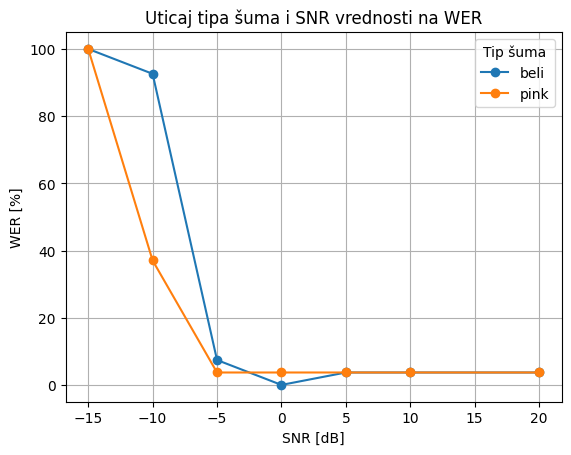

In [82]:
import matplotlib.pyplot as plt

tabela_pivot.plot(marker="o")

plt.xlabel("SNR [dB]")
plt.ylabel("WER [%]")
plt.title("Uticaj tipa šuma i SNR vrednosti na WER")
plt.grid(True)
plt.show()

## Uticaj pozadinskog šuma na Faster-Whisper

U ovom eksperimentu analiziran je uticaj pozadinskog šuma na tačnost prepoznavanja govora korišćenjem Faster-Whisper modela. Na originalni audio signal dodavani su beli i pink šum sa različitim SNR vrednostima (20 dB, 10 dB, 5 dB, 0 dB, -5 dB, -10 dB i -15 dB). Nakon toga izvršena je transkripcija i izračunat WER (Word Error Rate).

**Napomena:** Braon šum je prvobitno bio uključen u eksperiment, ali je izostavljen iz završne analize jer nije izazivao značajne promene u WER vrednostima čak ni pri veoma niskim SNR nivoima. Razlog je što najveći deo njegove energije pripada veoma niskim frekvencijama koje imaju mali uticaj na proces prepoznavanja govora.

### Analiza rezultata

Rezultati pokazuju da Faster-Whisper veoma dobro podnosi prisustvo šuma za SNR vrednosti od 20 dB do 0 dB, gde su WER vrednosti ostale gotovo nepromenjene.

Kod belog šuma dolazi do naglog pogoršanja performansi pri SNR = -10 dB (WER = 92.59%), dok je pri SNR = -15 dB model potpuno izgubio mogućnost ispravne transkripcije (WER = 100%).

Pink šum se pokazao manje destruktivnim. Pri SNR = -10 dB WER iznosi 37.04%, dok je potpuni gubitak tačnosti zabeležen tek pri SNR = -15 dB.

### Komentar grafika

Sa grafika se može uočiti da su performanse modela stabilne za veće SNR vrednosti, dok pri veoma jakom šumu dolazi do naglog rasta WER metrike. Beli šum ima znatno veći negativan uticaj na prepoznavanje govora od pink šuma, što ukazuje da tip šuma značajno utiče na kvalitet transkripcije.

### Zaključak

Eksperiment pokazuje da Faster-Whisper poseduje visoku otpornost na umerene nivoe pozadinskog šuma. Najveći pad performansi izaziva beli šum pri veoma niskim SNR vrednostima, dok je model znatno otporniji na pink šum. Dobijeni rezultati potvrđuju da Faster-Whisper može pouzdano da funkcioniše u realnim uslovima sa prisutnim pozadinskim šumom.